In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import hilbert, butter, filtfilt, spectrogram
from scipy.ndimage import gaussian_filter, gaussian_filter1d
import mne
from statsmodels.tsa.stattools import acf
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.mplot3d import Axes3D
from NeuralFieldManifold.models.ar import AR
from NeuralFieldManifold.embedders import embed

In [2]:
# ============== PREPROCESSING ==============
from scipy import signal
from scipy.signal import hilbert

def load_eeg_data(time_path, signal_path):
    """Load EEG data from numpy files."""
    time = np.load(time_path)
    signal_data = np.load(signal_path)
    fs = 1 / np.mean(np.diff(time))
    return time, signal_data, fs

def bandpass_filter(x, Fs, low, high, order=4):
    wn = [low/(Fs/2), high/(Fs/2)]
    sos = signal.butter(order, wn, btype='bandpass', output='sos')
    return signal.sosfiltfilt(sos, x)

def envelope_normalize(x, fs, fband=(15, 30), env_lp_hz=5.0, eps=1e-6):
    b, a = signal.butter(4, np.array(fband)/(fs/2), btype='bandpass')
    x_bp = signal.filtfilt(b, a, x)
    z = hilbert(x_bp)
    A = np.abs(z)
    if env_lp_hz is not None:
        b_lp, a_lp = signal.butter(2, env_lp_hz/(fs/2), btype='low')
        A = signal.filtfilt(b_lp, a_lp, A)
    x_flat = x_bp / (A + eps)
    x_flat *= np.median(A)
    return x_flat, x_bp, A

def process_eeg_signal(raw_signal, Fs, 
                       notch_freq=60, notch_Q=30,
                       bandpass_low=0.5, bandpass_high=40,
                       fband=(1, 40), env_lp_hz=3.0):
    """Process EEG signal with notch filter, bandpass, and envelope normalization."""
    filtered = signal.filtfilt(*signal.iirnotch(notch_freq, notch_Q, Fs), raw_signal)
    x = np.asarray(filtered).ravel()
    xs_raw = bandpass_filter(x, Fs, low=bandpass_low, high=bandpass_high)
    xs, _, _ = envelope_normalize(xs_raw, Fs, fband=fband, env_lp_hz=env_lp_hz)
    return xs, xs_raw

def fit_ar_model(xs, Fs, p=4, train_frac=0.9, refresh_every=5):
    X, y = AR.lag_matrix(xs, p)
    ntr = int(train_frac * len(y))
    X_tr, y_tr = X[:ntr], y[:ntr]
    w = AR.fit(X_tr, y_tr)
    N_te = len(y) - ntr
    t0 = p + ntr
    true_test = xs[t0 : t0 + N_te]
    yhat_ctrl = AR.hybrid_predict(xs, w, p, start_idx=t0, n_steps=N_te, refresh_every=refresh_every)
    full_pred = AR.hybrid_predict(xs, w, p, start_idx=p, n_steps=len(xs)-p, refresh_every=refresh_every)
    xs_pred_full = np.concatenate([xs[:p], full_pred])
    mse, mae, corr = AR.metrics(true_test, yhat_ctrl)
    return {
        'w': w, 'p': p, 'ntr': ntr, 'y': y, 'true_test': true_test,
        'yhat_ctrl': yhat_ctrl, 'xs_pred_full': xs_pred_full, 't0': t0,
        'mse': mse, 'mae': mae, 'corr': corr, 'refresh_every': refresh_every
    }

def embed3(s, tau):
    """Create 3D delay embedding"""
    return np.column_stack([s[2*tau:], s[tau:-tau], s[:-2*tau]])

print("AR class imported.")

AR class imported.


In [3]:
# Load data using the simpler function
# time_proc, raw_signal, fs_proc = load_eeg_data(
#     '/Users/novak/Documents/UTSW/erfan/eegeeg_time.npy',
#     '/Users/novak/Documents/UTSW/erfan/eegeeg_signal.npy'
# )

time_proc, raw_signal, fs_proc = load_eeg_data(
    'data/eeg_time_sec3.npy',
    'data/eeg_signal_sec3.npy'
)

# Process the signal
preprocessed, xs_raw = process_eeg_signal(raw_signal, fs_proc)

snippet_sec = 25  # seconds to display
start_idx = 8000  # start index to avoid edge effects
N_snip = int(snippet_sec * fs_proc)

filtered = preprocessed[start_idx:start_idx+N_snip]
t_snip = time_proc[start_idx:start_idx+N_snip]
x_snip = filtered

print(f"Loaded EEG: {len(raw_signal)} samples at {fs_proc:.2f} Hz")
print(f"Duration: {time_proc[-1] - time_proc[0]:.2f} seconds")
print(f"Snippet contains: {snippet_sec} seconds")

Loaded EEG: 1440000 samples at 400.00 Hz
Duration: 3600.00 seconds
Snippet contains: 25 seconds


In [4]:
# ============== GLOBAL PLOT STYLE ==============
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "lines.linewidth": 1.8,
    "lines.markersize": 5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

color_main = "black"
color_alt = "darkred"

def prettify(ax, title=None, xlabel=None, ylabel=None, add_legend=False):
    """Unified styling for axes"""
    if title: ax.set_title(title, pad=10)
    if xlabel: ax.set_xlabel(xlabel, labelpad=5)
    if ylabel: ax.set_ylabel(ylabel, labelpad=5)
    ax.grid(alpha=0.0, linestyle="--", linewidth=0.7)
    if add_legend: 
        ax.legend(frameon=False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(1.0)

print("Plot style configured.")

Plot style configured.


In [5]:
plot_sec = 5
plot_n_snip = int(plot_sec * fs_proc)

plot_x_snip = preprocessed[start_idx:start_idx+plot_n_snip]
plot_t_snip = time_proc[start_idx:start_idx+plot_n_snip]



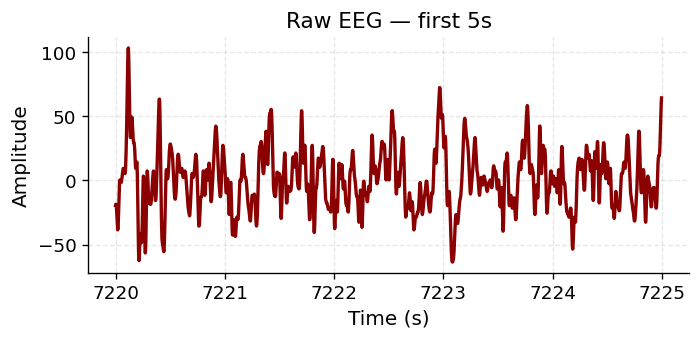

In [6]:
# ============== PLOT: Raw Time Series ==============
DATA_TYPE = "EEG"  # Options: "EEG" (scalp) or "LFP" (intracranial)

# Get raw signal snippet (same time window as filtered)
raw_x_snip = raw_signal[start_idx:start_idx+plot_n_snip]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(plot_t_snip, raw_x_snip, lw=2.0, color=color_alt)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Raw {DATA_TYPE} — first {plot_sec}s")
ax.grid(True, ls='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
 

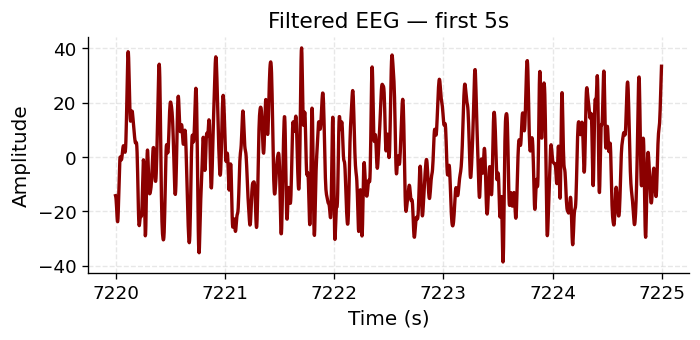

In [7]:
# ============== PLOT (a): Filtered Time Series ==============
# Data type label (change based on your data)
DATA_TYPE = "EEG"  # Options: "EEG" (scalp) or "LFP" (intracranial)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(plot_t_snip, plot_x_snip, lw=2.0, color=color_alt)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Filtered {DATA_TYPE} — first {plot_sec}s")
ax.grid(True, ls='--', alpha=0.3)
ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
 

/tmp/ipykernel_12319/645307803.py:27: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([0,50])


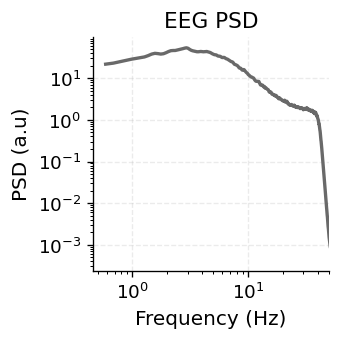

In [8]:
# ============== PLOT (c): PSD ==============
# PSD frequency range depends on data type:
#   EEG (scalp): 0.5-50 Hz (higher is mostly artifact)
#   LFP (intracranial): 0.5-200 Hz (can see gamma/ripples)

# PSD_FMAX = 50.0 if DATA_TYPE == "EEG" else 200.0

# Compute PSD using Welch method
psd, freqs = mne.time_frequency.psd_array_welch(
    raw_signal[None, :],
    sfreq=fs_proc,
    fmin=0.5, fmax=100,
    n_fft=4096,
    n_overlap=2048,
    average='mean',
    verbose=False
)
psd = psd[0]

# Smooth PSD
psd_smooth = gaussian_filter1d(psd, sigma=1)

# Plot PSD
fig, ax = plt.subplots(figsize=(3, 3))
ax.loglog(freqs, psd_smooth, 'dimgray', lw=2)
ax.set_xlabel("Frequency (Hz)")
ax.set_xlim([0,50])
ax.set_ylabel("PSD (a.u)")
ax.set_title(f"{DATA_TYPE} PSD")
ax.grid(True, ls="--", alpha=0.25)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

Best p by MSE: p=6


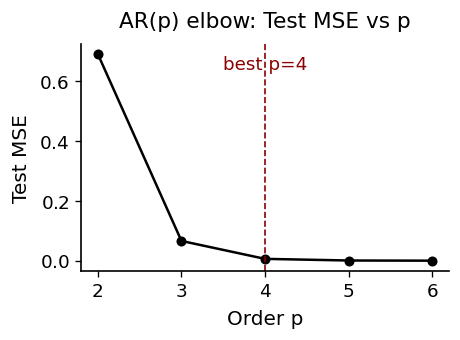

In [9]:
# ============== AR MODEL FITTING ==============
# Sweep AR orders for elbow plot
p_list = list(range(2, 7))
mse_te_list = []
params_by_p = {}

# filtered = raw_signal
for p in p_list:
    X, y = AR.lag_matrix(filtered, p)
    ntr = int(0.9 * len(y))
    X_tr, y_tr = X[:ntr], y[:ntr]
    X_te, y_te = X[ntr:], y[ntr:]
    w = AR.fit(X_tr, y_tr)
    yhat_te = AR.predict_from_params(X_te, w)
    mse_te, _, _ = AR.metrics(y_te, yhat_te)
    mse_te_list.append(mse_te)
    params_by_p[p] = w

best_p_by_mse = p_list[int(np.argmin(mse_te_list))]
print(f"Best p by MSE: p={best_p_by_mse}")
best_p_by_mse = 4

def plot_mse_elbow(p_list, mse_list, best_p, color_main="black", color_alt="darkred"):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(p_list, mse_list, marker='o', color=color_main, lw=1.5, ms=5)
    ax.axvline(best_p, linestyle='--', color=color_alt, linewidth=1)
    ax.text(best_p, ax.get_ylim()[1]*0.95, f"best p={best_p}", ha='center', va='top', color=color_alt, fontsize=11)
    sf = ScalarFormatter(useMathText=True)
    sf.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(sf)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, 3))
    ax.yaxis.get_offset_text().set_size(10)
    prettify(ax, title="AR(p) elbow: Test MSE vs p", xlabel="Order p", ylabel="Test MSE")
    plt.tight_layout()
    plt.show()

plot_mse_elbow(p_list, mse_te_list, best_p_by_mse)

In [10]:
ar_results = fit_ar_model(filtered, fs_proc, p=best_p_by_mse, train_frac=0.8, refresh_every=5)

w = ar_results['w']
p_use = ar_results['p']
ntr = ar_results['ntr']
y = ar_results['y']
true_test = ar_results['true_test']
yhat_ctrl = ar_results['yhat_ctrl']
xs_pred_full = ar_results['xs_pred_full']
REFRESH_EVERY = ar_results['refresh_every']

print(f"AR({p_use}): MSE={ar_results['mse']:.6f}, corr={ar_results['corr']:.3f}")

AR(4): MSE=3.488139, corr=0.993


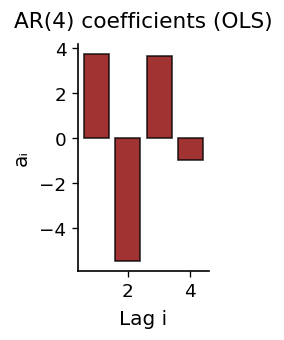

In [11]:
def plot_ar_coefficients(w, p, color_main="black", color_alt="darkred"):
    fig, ax = plt.subplots(figsize=(2, 3))
    ax.bar(np.arange(1, p+1), w[1:], color=color_alt, edgecolor=color_main, alpha=0.8)
    prettify(ax, title=f"AR({p}) coefficients (OLS)", xlabel="Lag i", ylabel="aᵢ")
    plt.tight_layout()
    plt.show()

plot_ar_coefficients(w, p_use)

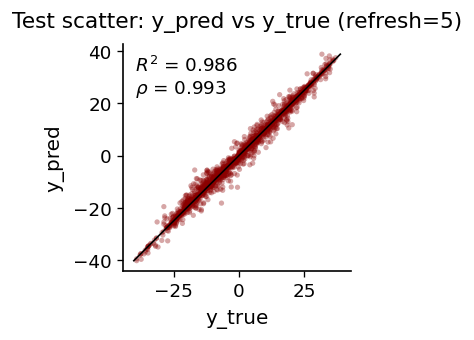

In [12]:
def plot_scatter(y_true, y_pred, refresh, color_main="black", color_alt="darkred"):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.scatter(y_true, y_pred, c=color_alt, alpha=0.35, s=10, edgecolors="none")
    vmin, vmax = min(np.min(y_true), np.min(y_pred)), max(np.max(y_true), np.max(y_pred))
    ax.plot([vmin, vmax], [vmin, vmax], color=color_main, lw=1)
    yt = y_true - np.mean(y_true)
    yp = y_pred - np.mean(y_pred)
    corr = float((yt @ yp) / np.sqrt((yt @ yt) * (yp @ yp) + 1e-12))
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res / (ss_tot + 1e-12)
    ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}\n$\\rho$ = {corr:.3f}",
            transform=ax.transAxes, ha='left', va='top', fontsize=11,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, boxstyle="round"))
    ax.set_aspect('equal', adjustable='box')
    prettify(ax, title=f"Test scatter: y_pred vs y_true (refresh={refresh})", xlabel="y_true", ylabel="y_pred")
    plt.tight_layout()
    plt.show()

plot_scatter(y[ntr:], yhat_ctrl, REFRESH_EVERY)

/tmp/ipykernel_12319/1126182785.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5)


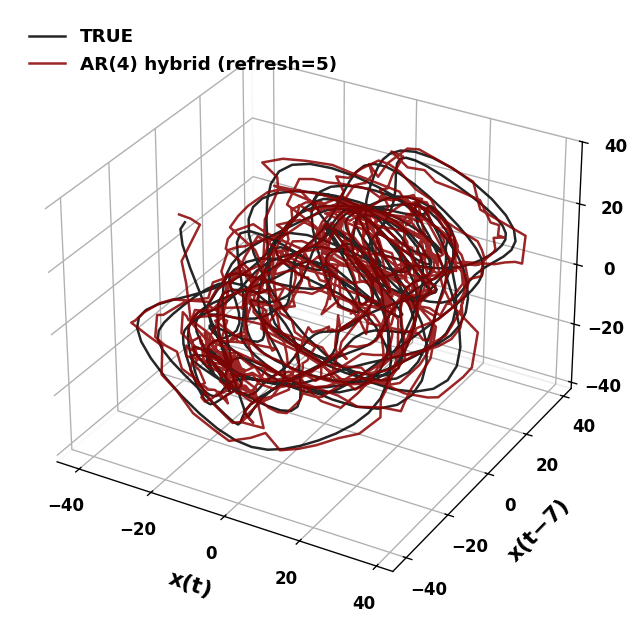

In [13]:
def plot_state_space(
    X3_true, X3_pred, p, tau, refresh,
    color_true="black", color_pred="darkred", pred_label=None
):
    from matplotlib.ticker import MaxNLocator
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    if pred_label is None:
        pred_label = f"AR({p}) hybrid (refresh={refresh})"

    ax.plot(X3_true[:, 0], X3_true[:, 1], X3_true[:, 2],
            label="TRUE", color=color_true, alpha=0.85, lw=1.5)
    ax.plot(X3_pred[:, 0], X3_pred[:, 1], X3_pred[:, 2],
            label=pred_label, color=color_pred, alpha=0.85, lw=1.5)

    # Bold axis labels (LaTeX)
    ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=8, fontsize=13)
    ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau})}}$", labelpad=8, fontsize=13)
    ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau})}}$", labelpad=8, fontsize=13)

    # Limit tick count to avoid crowding
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.zaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(axis='both', pad=4, labelsize=10)

    # Bold tick labels
    for label in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels() + ax.zaxis.get_ticklabels():
        label.set_fontweight('bold')

    # Remove grey background panes
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.legend(frameon=False, loc='upper left', fontsize=11, prop={'weight': 'bold'})
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.12, top=0.95)
    plt.tight_layout(pad=2.5)
    plt.show()

tau = 7
hy = yhat_ctrl - np.mean(yhat_ctrl)
hy = hy * (np.std(true_test) / (np.std(hy) + 1e-12)) + np.mean(true_test)

X3_true = embed(true_test, 3, tau)
X3_hyb = embed(hy, 3, tau)

plot_state_space(X3_true[:1200], X3_hyb[:1200], p_use, tau, REFRESH_EVERY)

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

from NeuralFieldManifold.models import DeepLagEmbed as DeepLagField
from NeuralFieldManifold.utils.losses import loss_ar, loss_energy, loss_smooth, loss_order


def plot_state_space_windows_comparison(xs, xs_pred, Fs, tau, embed_dim=3,
                                         windows=[(6, 8), (8, 10), (10, 12), (12, 14)], pred_label=None):
    fig, axes = plt.subplots(1, 4, figsize=(len(windows) * 4.5, 5), subplot_kw={'projection': '3d'})
    if pred_label is None:
        pred_label = f'AR({p_use}) pred'

    for ax, (t_start, t_end) in zip(axes, windows):
        idx_start = int(t_start * Fs)
        idx_end = int(t_end * Fs)

        segment_true = xs[idx_start:idx_end]
        X3_true = embed(segment_true, embed_dim, tau)

        segment_pred = xs_pred[idx_start:idx_end]
        seg_pred_matched = segment_pred - np.mean(segment_pred)
        seg_pred_matched = seg_pred_matched * (np.std(segment_true) / (np.std(seg_pred_matched) + 1e-12))
        seg_pred_matched = seg_pred_matched + np.mean(segment_true)
        X3_pred = embed(seg_pred_matched, embed_dim, tau)

        ax.plot(X3_true[:, 0], X3_true[:, 1], X3_true[:, 2], color='black', alpha=0.85, lw=1.5, label='True')
        ax.plot(X3_pred[:, 0], X3_pred[:, 1], X3_pred[:, 2], color='darkred', alpha=0.85, lw=1.5, label=pred_label)

        ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=8, fontsize=13)
        ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau})}}$", labelpad=8, fontsize=13)
        ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau})}}$", labelpad=8, fontsize=13)

        from matplotlib.ticker import MaxNLocator
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.zaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.tick_params(axis='both', pad=4, labelsize=10)

        for label in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels() + ax.zaxis.get_ticklabels():
            label.set_fontweight('bold')

        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False

        ax.text2D(0.5, -0.12, f"$\\mathbf{{{t_start}\\!-\\!{t_end} \\; s}}$",
                  transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold')

    axes[0].legend(frameon=False, loc='upper left', fontsize=11,
                   prop={'weight': 'bold'})
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.12, top=0.95, wspace=0.15)
    plt.tight_layout(pad=2.5, w_pad=1.5)
    plt.show()


def plot_state_space_tau_sweep(xs, xs_pred, Fs, t_start, t_end, taus, embed_dim=3, pred_label=None):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={'projection': '3d'})
    if pred_label is None:
        pred_label = f'AR({p_use}) pred'

    idx_start = int(t_start * Fs)
    idx_end = int(t_end * Fs)
    segment_true = xs[idx_start:idx_end]
    segment_pred = xs_pred[idx_start:idx_end]

    seg_pred_matched = segment_pred - np.mean(segment_pred)
    seg_pred_matched = seg_pred_matched * (np.std(segment_true) / (np.std(seg_pred_matched) + 1e-12))
    seg_pred_matched = seg_pred_matched + np.mean(segment_true)

    for ax, tau_val in zip(axes, taus):
        X3_true = embed(segment_true, embed_dim, tau_val)
        X3_pred = embed(seg_pred_matched, embed_dim, tau_val)

        ax.plot(X3_true[:, 0], X3_true[:, 1], X3_true[:, 2], color='black', alpha=0.85, lw=1.5, label='True')
        ax.plot(X3_pred[:, 0], X3_pred[:, 1], X3_pred[:, 2], color='darkred', alpha=0.85, lw=1.5, label=pred_label)

        ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=8, fontsize=13)
        ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau_val})}}$", labelpad=8, fontsize=13)
        ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau_val})}}$", labelpad=8, fontsize=13)

        from matplotlib.ticker import MaxNLocator
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.zaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.tick_params(axis='both', pad=4, labelsize=10)

        for label in ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels() + ax.zaxis.get_ticklabels():
            label.set_fontweight('bold')

        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False

        ax.text2D(0.5, -0.12, f"$\\mathbf{{\\tau = {tau_val}}}$",
                  transform=ax.transAxes, ha='center', fontsize=14, fontweight='bold')

    axes[0].legend(frameon=False, loc='upper left', fontsize=11,
                   prop={'weight': 'bold'})
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.12, top=0.95, wspace=0.15)
    plt.tight_layout(pad=2.5, w_pad=1.5)
    plt.show()


def make_lfp_windows(x, seq_len=600, stride=120):
    x = np.asarray(x, dtype=np.float32)
    starts = np.arange(0, len(x) - seq_len + 1, stride, dtype=int)
    windows = np.stack([x[s:s + seq_len] for s in starts]).astype(np.float32)
    return windows, starts


def normalize_windows(windows):
    mu = windows.mean(axis=1, keepdims=True)
    sigma = windows.std(axis=1, keepdims=True) + 1e-6
    return (windows - mu) / sigma, mu.squeeze(1), sigma.squeeze(1)


def train_deeplagfield_on_lfp(
    xs,
    seq_len=600,
    stride=120,
    max_ar_order=6,
    hidden_dim=128,
    batch_size=32,
    n_epochs=200,
    lr=1e-3,
    lambda_ar=1.0,
    lambda_energy=1e-3,
    lambda_smooth=1e-2,
    lambda_order=1e-3,
    temperature=1.0,
    seed=7,
):
    torch.manual_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    windows, starts = make_lfp_windows(xs, seq_len=seq_len, stride=stride)
    windows_norm, mu, sigma = normalize_windows(windows)

    X = torch.tensor(windows_norm, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=True)

    model = DeepLagField(
        seq_len=seq_len,
        n_classes=max_ar_order - 1,
        max_ar_order=max_ar_order,
        hidden_dim=hidden_dim,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "ar": [], "energy": [], "smooth": [], "order": []}

    for epoch in range(n_epochs):
        model.train()
        totals = {k: [] for k in history}

        for (xb,) in loader:
            xb = xb.to(device)
            optimizer.zero_grad()

            coeffs, p_logits, _, x_hat = model(xb, temperature=temperature)

            l_ar = loss_ar(xb, x_hat, max_ar_order)
            l_energy = loss_energy(x_hat, P0=1.0, W=40)
            l_smooth = loss_smooth(coeffs)
            l_order = loss_order(p_logits)

            loss = (
                lambda_ar * l_ar
                + lambda_energy * l_energy
                + lambda_smooth * l_smooth
                + lambda_order * l_order
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            totals["loss"].append(float(loss.detach().cpu()))
            totals["ar"].append(float(l_ar.detach().cpu()))
            totals["energy"].append(float(l_energy.detach().cpu()))
            totals["smooth"].append(float(l_smooth.detach().cpu()))
            totals["order"].append(float(l_order.detach().cpu()))

        for key in history:
            history[key].append(float(np.mean(totals[key])))

        if epoch == 0 or (epoch + 1) % 25 == 0 or epoch == n_epochs - 1:
            print(
                f"epoch {epoch + 1:4d}/{n_epochs} | "
                f"loss={history['loss'][-1]:.5f} | "
                f"ar={history['ar'][-1]:.5f} | "
                f"smooth={history['smooth'][-1]:.5f}"
            )

    return {
        "model": model,
        "history": history,
        "windows": windows,
        "windows_norm": windows_norm,
        "starts": starts,
        "mu": mu,
        "sigma": sigma,
        "seq_len": seq_len,
        "stride": stride,
        "max_ar_order": max_ar_order,
        "device": device,
    }


def deeplagfield_predict_all(result, batch_size=64, temperature=0.25):
    model = result["model"]
    device = result["device"]

    X = torch.tensor(result["windows_norm"], dtype=torch.float32)
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=False)

    coeffs_all, p_all, xhat_all = [], [], []

    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            coeffs, _, p_hard, x_hat = model(xb, temperature=temperature)
            coeffs_all.append(coeffs.cpu().numpy())
            p_all.append(p_hard.cpu().numpy())
            xhat_all.append(x_hat.cpu().numpy())

    coeffs_all = np.concatenate(coeffs_all, axis=0)
    p_all = np.concatenate(p_all, axis=0)
    xhat_norm = np.concatenate(xhat_all, axis=0)
    xhat = xhat_norm * result["sigma"][:, None] + result["mu"][:, None]

    return {
        "coeffs": coeffs_all,
        "p_class": p_all,
        "p_order": p_all + 2,
        "xhat_norm": xhat_norm,
        "xhat": xhat,
    }


def overlap_add_windows(windows, starts, signal_len):
    out = np.zeros(signal_len, dtype=float)
    weight = np.zeros(signal_len, dtype=float)

    for win, start in zip(windows, starts):
        end = min(start + len(win), signal_len)
        n = end - start
        out[start:end] += win[:n]
        weight[start:end] += 1.0

    valid = weight > 0
    out[valid] /= weight[valid]
    out[~valid] = np.nan
    return out, valid

In [15]:
deeplag_result = train_deeplagfield_on_lfp(
    filtered,
    seq_len=min(1600, len(filtered)),
    stride=120,
    max_ar_order=5,
    hidden_dim=256,
    batch_size=16,
    n_epochs=300,
    lr=1e-3,
    lambda_ar=3.0,
    lambda_energy=1e-3,
    lambda_smooth=1e-2,
    lambda_order=1e-3,
    temperature=1.0,
    seed=7,
)

deeplag_pred = deeplagfield_predict_all(deeplag_result, temperature=0.25)

xs_deeplag_full, deeplag_valid = overlap_add_windows(
    deeplag_pred["xhat"],
    deeplag_result["starts"],
    len(filtered),
)

print(f"Windows: {deeplag_result['windows'].shape[0]}")
print(f"Predicted TVAR orders: {dict(zip(*np.unique(deeplag_pred['p_order'], return_counts=True)))}")

epoch    1/300 | loss=2.17593 | ar=0.72428 | smooth=0.11051
epoch   25/300 | loss=0.06396 | ar=0.02094 | smooth=0.09592
epoch   50/300 | loss=0.01740 | ar=0.00551 | smooth=0.06955
epoch   75/300 | loss=0.08018 | ar=0.02645 | smooth=0.05353
epoch  100/300 | loss=0.01725 | ar=0.00555 | smooth=0.04213
epoch  125/300 | loss=0.00651 | ar=0.00200 | smooth=0.03566
epoch  150/300 | loss=0.02693 | ar=0.00883 | smooth=0.02966
epoch  175/300 | loss=0.00278 | ar=0.00079 | smooth=0.02819
epoch  200/300 | loss=0.06051 | ar=0.01997 | smooth=0.03019
epoch  225/300 | loss=0.00458 | ar=0.00139 | smooth=0.02484
epoch  250/300 | loss=0.00147 | ar=0.00037 | smooth=0.02274
epoch  275/300 | loss=0.00661 | ar=0.00208 | smooth=0.02216
epoch  300/300 | loss=0.03036 | ar=0.00998 | smooth=0.02288
Windows: 70
Predicted TVAR orders: {np.int64(2): np.int64(70)}


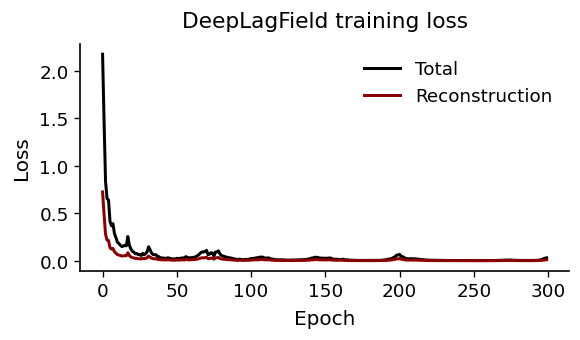

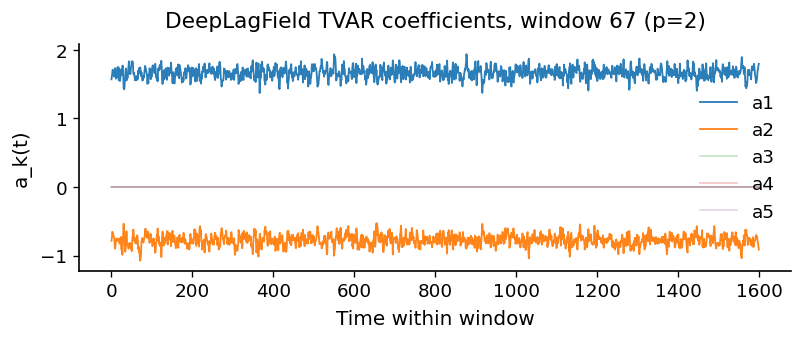

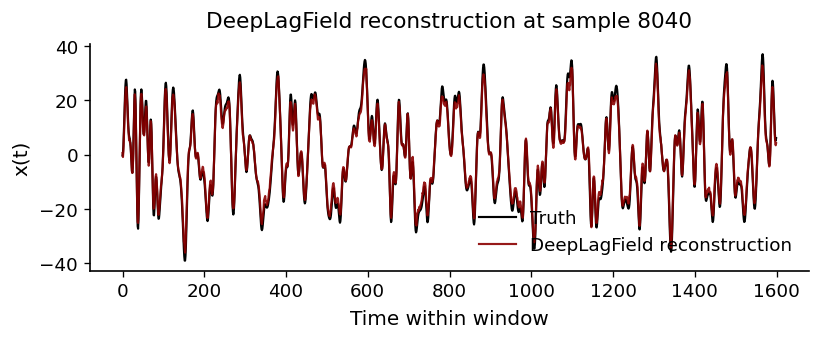

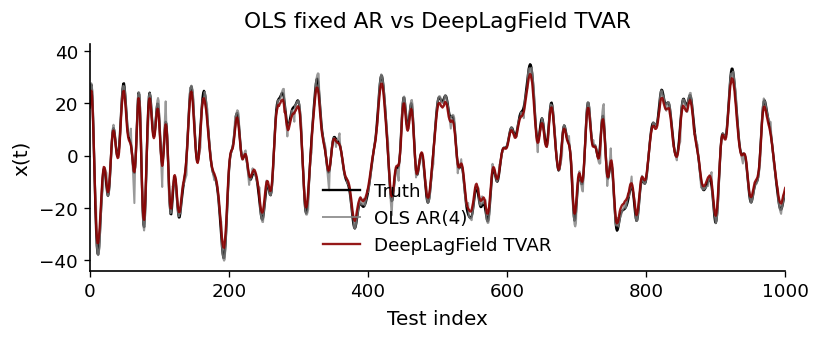

DeepLagField test overlap: MSE=4.111360, corr=0.9992


In [16]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(deeplag_result["history"]["loss"], color="black", label="Total")
ax.plot(deeplag_result["history"]["ar"], color="darkred", label="Reconstruction")
prettify(ax, title="DeepLagField training loss", xlabel="Epoch", ylabel="Loss", add_legend=True)
plt.tight_layout()
plt.show()

test_start = p_use + ntr
test_candidates = np.where(deeplag_result["starts"] >= test_start)[0]
example_idx = int(test_candidates[0]) if len(test_candidates) else len(deeplag_result["starts"]) // 2

example_start = int(deeplag_result["starts"][example_idx])
example_true = deeplag_result["windows"][example_idx]
example_xhat = deeplag_pred["xhat"][example_idx]
example_coeffs = deeplag_pred["coeffs"][example_idx]
example_order = int(deeplag_pred["p_order"][example_idx])

fig, ax = plt.subplots(figsize=(7, 3))
for k in range(deeplag_result["max_ar_order"]):
    alpha = 0.95 if k < example_order else 0.25
    ax.plot(example_coeffs[:, k], lw=1.1, alpha=alpha, label=f"a{k+1}")

prettify(
    ax,
    title=f"DeepLagField TVAR coefficients, window {example_idx} (p={example_order})",
    xlabel="Time within window",
    ylabel="a_k(t)",
    add_legend=True,
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(example_true, color="black", lw=1.3, label="Truth")
ax.plot(example_xhat, color="darkred", lw=1.3, alpha=0.9, label="DeepLagField reconstruction")
prettify(
    ax,
    title=f"DeepLagField reconstruction at sample {example_start}",
    xlabel="Time within window",
    ylabel="x(t)",
    add_legend=True,
)
plt.tight_layout()
plt.show()

deeplag_test_pred = xs_deeplag_full[p_use + ntr:p_use + ntr + len(yhat_ctrl)]
deeplag_test_true = y[ntr:ntr + len(deeplag_test_pred)]
mask = np.isfinite(deeplag_test_pred)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(deeplag_test_true, color="black", lw=1.4, label="Truth")
ax.plot(
    yhat_ctrl[:len(deeplag_test_true)],
    color="gray",
    lw=1.2,
    alpha=0.8,
    label=f"OLS AR({p_use})",
)
ax.plot(
    deeplag_test_pred,
    color="darkred",
    lw=1.4,
    alpha=0.9,
    label="DeepLagField TVAR",
)
prettify(
    ax,
    title="OLS fixed AR vs DeepLagField TVAR",
    xlabel="Test index",
    ylabel="x(t)",
    add_legend=True,
)
ax.set_xlim(0, min(1000, len(deeplag_test_true)))
plt.tight_layout()
plt.show()

if mask.any():
    mse_dle = float(np.mean((deeplag_test_true[mask] - deeplag_test_pred[mask]) ** 2))
    corr_dle = float(np.corrcoef(deeplag_test_true[mask], deeplag_test_pred[mask])[0, 1])
    print(f"DeepLagField test overlap: MSE={mse_dle:.6f}, corr={corr_dle:.4f}")

/tmp/ipykernel_12319/1126182785.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5)


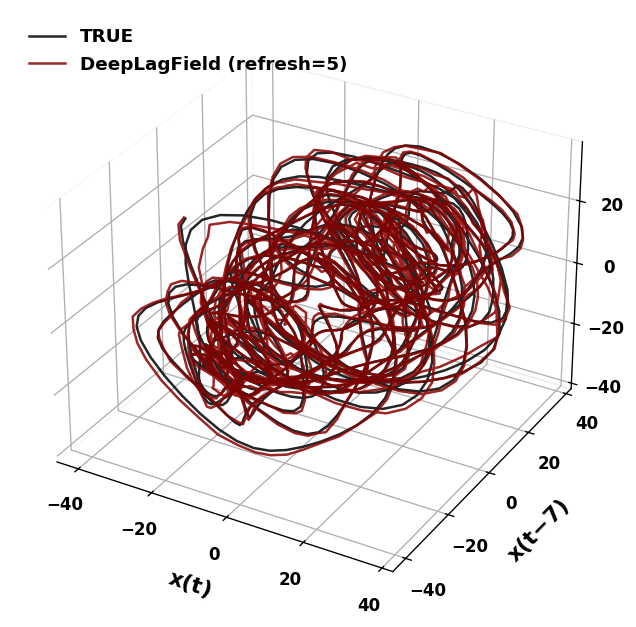

In [17]:
segment_true = deeplag_test_true[mask]
segment_pred = deeplag_test_pred[mask]

segment_pred_matched = segment_pred - np.mean(segment_pred)
segment_pred_matched = (
    segment_pred_matched
    * (np.std(segment_true) / (np.std(segment_pred_matched) + 1e-12))
    + np.mean(segment_true)
)

X3_true_dle = embed(segment_true, m=3, tau=tau)
X3_dle = embed(segment_pred_matched, m=3, tau=tau)

plot_state_space(
    X3_true_dle,
    X3_dle,
    example_order,
    tau,
    REFRESH_EVERY,
    pred_label=f"DeepLagField (refresh={REFRESH_EVERY})",
)

/tmp/ipykernel_12319/489650572.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


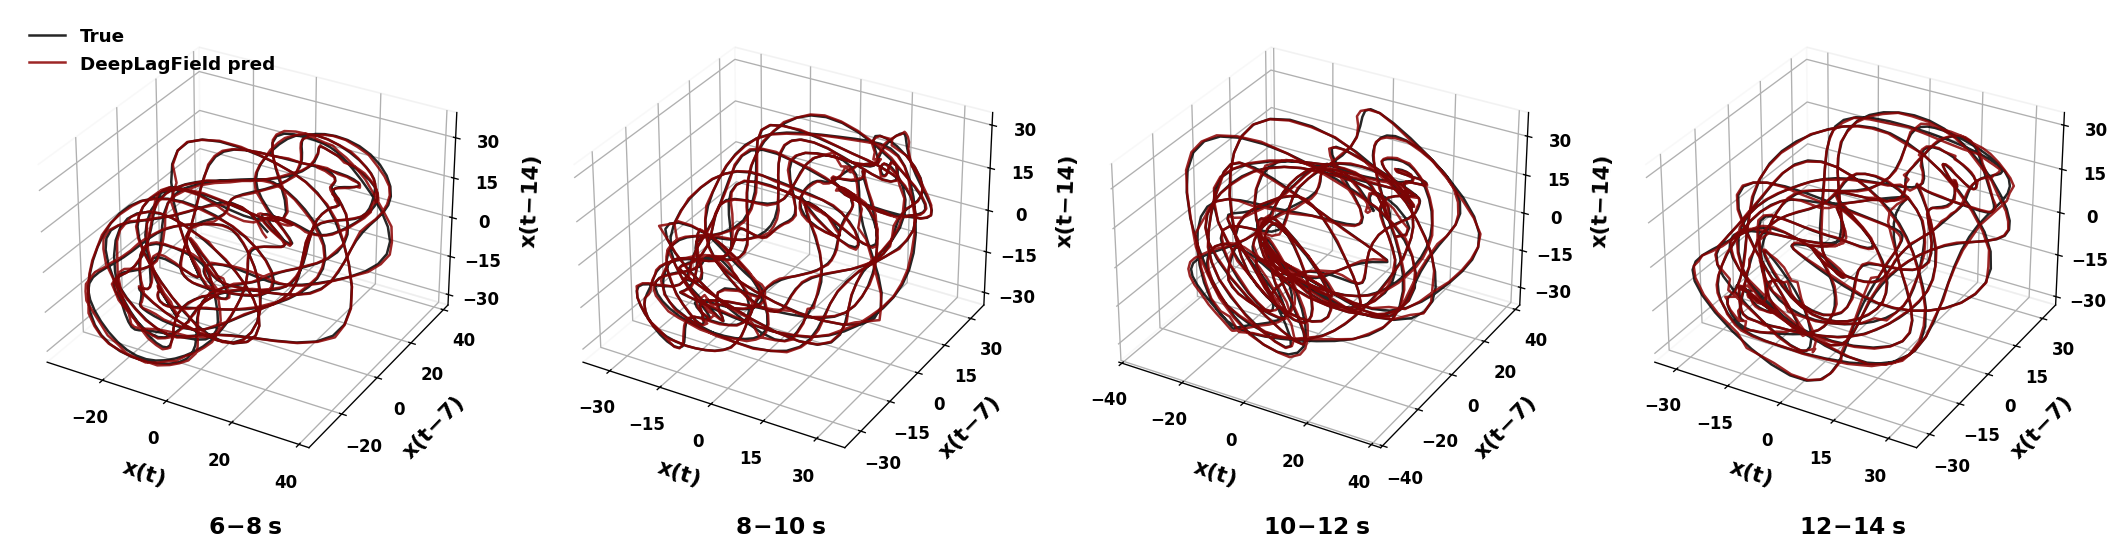

/tmp/ipykernel_12319/489650572.py:101: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.5)


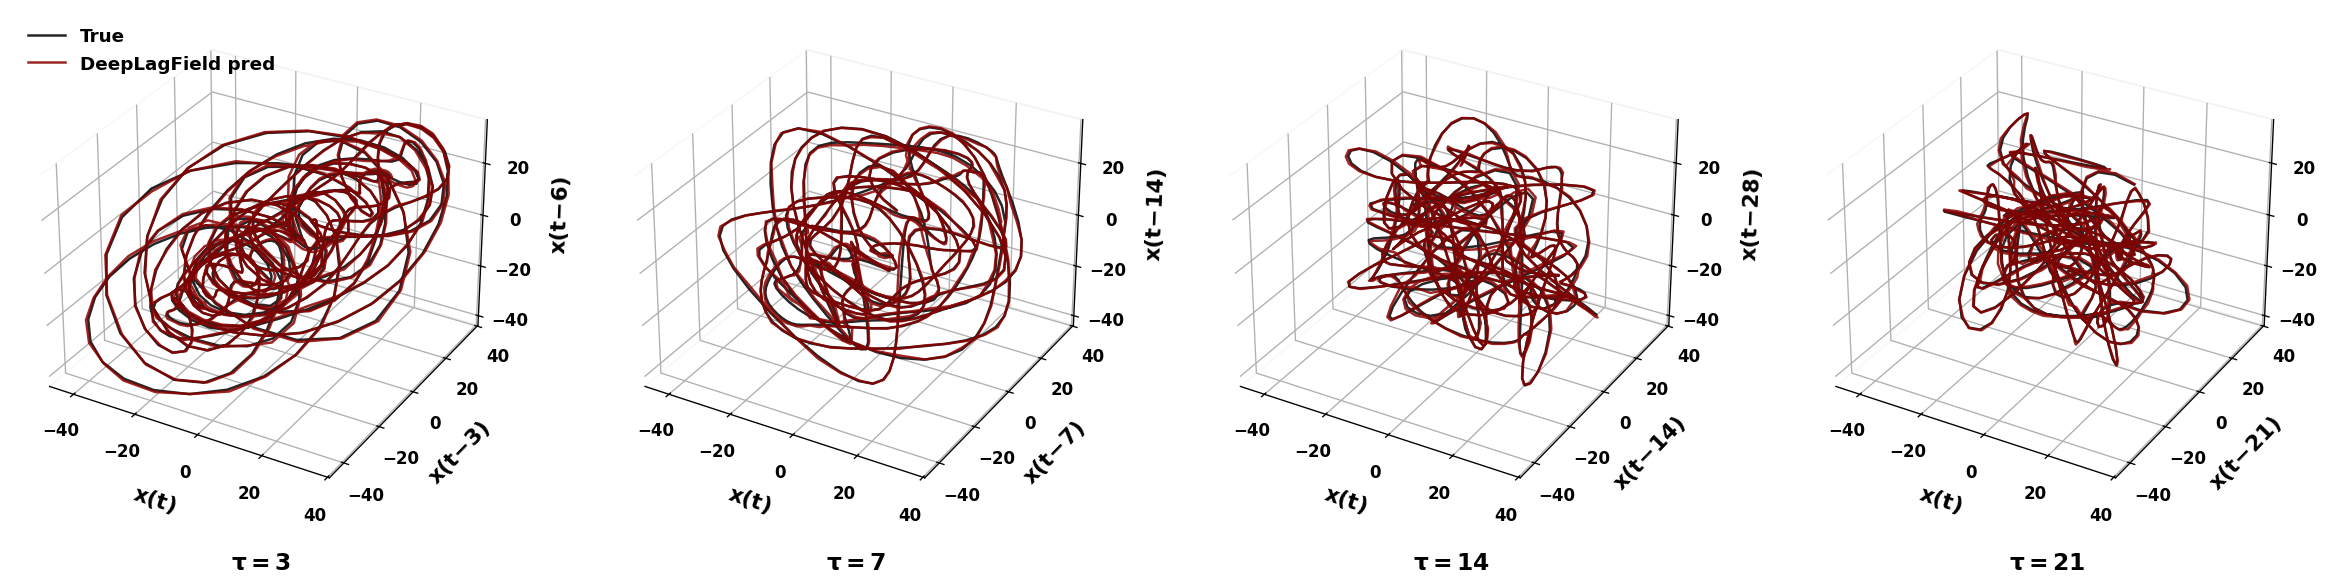

In [18]:
filled_deeplag = np.nan_to_num(xs_deeplag_full, nan=np.nanmean(filtered))

tau_sweep_values = [max(1, tau // 2), tau, 2 * tau, 3 * tau]

plot_state_space_windows_comparison(
    filtered,
    filled_deeplag,
    fs_proc,
    tau,
    pred_label="DeepLagField pred",
)

plot_state_space_tau_sweep(
    filtered,
    filled_deeplag,
    fs_proc,
    t_start=18,
    t_end=20,
    taus=tau_sweep_values,
    pred_label="DeepLagField pred",
)

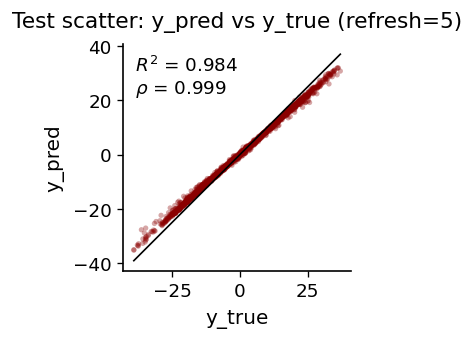

In [19]:
plot_scatter(
    deeplag_test_true[mask],
    deeplag_test_pred[mask],
    REFRESH_EVERY,
)